In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#from statannot import add_stat_annotation
import anndata as an
#import diffxpy.api as de
from scipy.stats import hypergeom
import seaborn as sns
#import symphonypy as sp
import matplotlib as mpl
from copy import copy
mpl.rc('pdf', fonttype=42)
#from statannot import add_stat_annotation
from statannotations.Annotator import Annotator

In [2]:
adata_RG_all= sc.read('/miridan-storage/miridan/wexac_backup/human_development_adata/ClassRadialGlia_for_harmony.h5ad' , backed="r")

In [3]:
adata_RG_all_gt5 = adata_RG_all[adata_RG_all.obs['Age']!=5,:].to_memory()

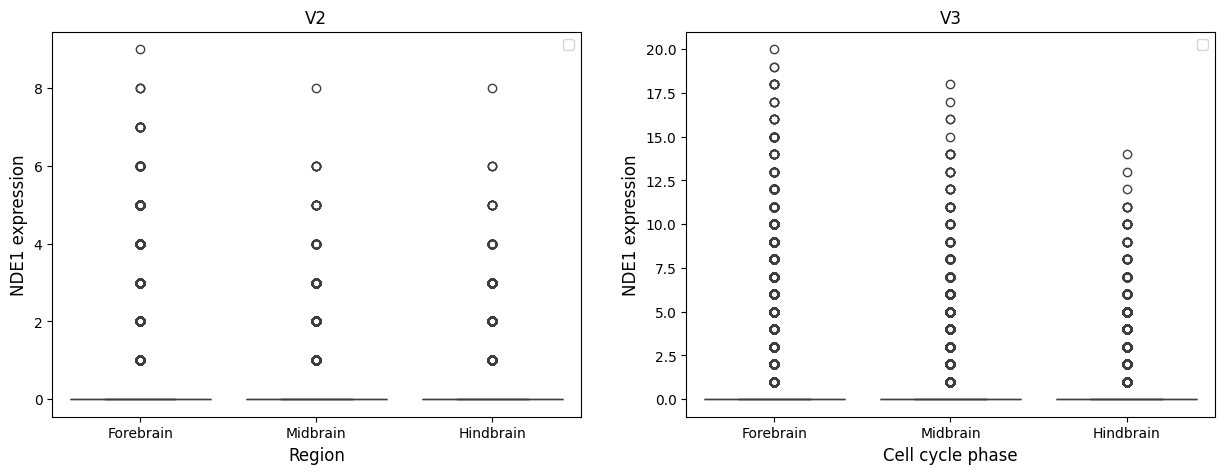

In [6]:
adata_RG_all_gt5_V2 = adata_RG_all_gt5[np.where(adata_RG_all_gt5.obs['Chemistry']=='v2')[0],:].copy()
adata_RG_all_gt5_V3 = adata_RG_all_gt5[np.where(adata_RG_all_gt5.obs['Chemistry']=='v3')[0],:].copy()
adata_RG_all_gt5_V2.obs['NDE1'] =  adata_RG_all_gt5_V2.layers['counts'][:,adata_RG_all_gt5_V2.var_names=='ENSG00000072864'].toarray().flatten()
adata_RG_all_gt5_V3.obs['NDE1'] =  adata_RG_all_gt5_V3.layers['counts'][:,adata_RG_all_gt5_V3.var_names=='ENSG00000072864'].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V2.obs)
axs[0].set_xlabel("Region", fontsize= 12)
axs[0].set_ylabel("NDE1 expression", fontsize= 12)
axs[0].set_title("V2", fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 
ax = sns.boxplot(ax = axs[1],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V3.obs)
axs[1].set_xlabel("Region", fontsize= 12)
axs[1].set_ylabel("NDE1 expression", fontsize= 12)
axs[1].set_title("V3", fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Hindbrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:5.160e-01 U_stat=1.164e+07
Forebrain vs. Hindbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:4.265e-45 U_stat=5.755e+07
Forebrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:5.258e-32 U_stat=4.300e+07
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Hindbrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:6.366e-02 U_stat=3.929e+07
Forebrain vs. Hindbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:9.218e-09 U_stat=8.964e+07
Forebrain vs. Midbrain: Mann-Whitney-Wilcoxon test two-sided, P_val:1.036e-20 U_stat=1.521e+08


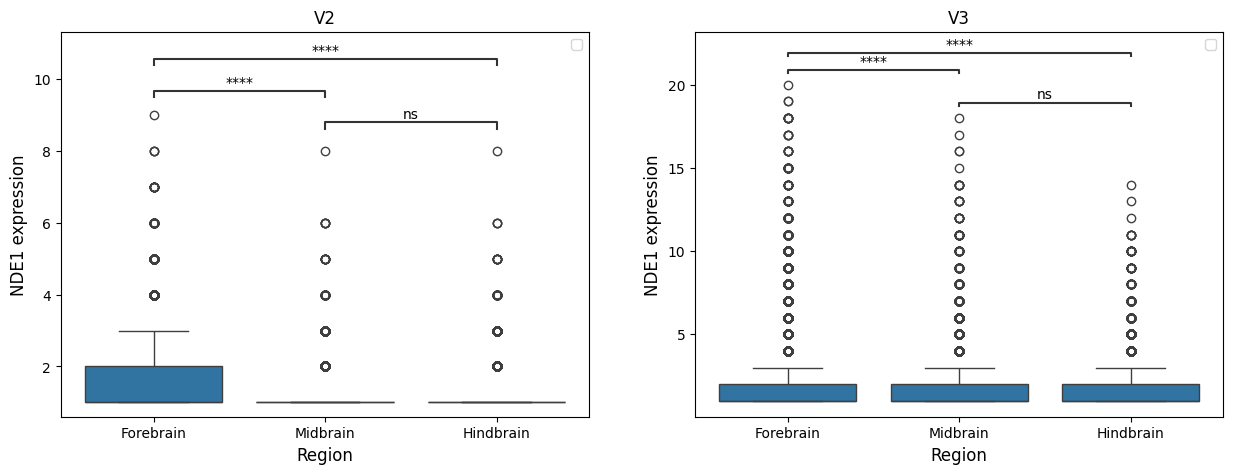

In [19]:

#Considering only cells that express NDE1
adata_RG_all_gt5_V2.obs['NDE1'] =  adata_RG_all_gt5_V2.layers['counts'][:,adata_RG_all_gt5_V2.var_names=='ENSG00000072864'].toarray().flatten()
adata_RG_all_gt5_V3.obs['NDE1'] =  adata_RG_all_gt5_V3.layers['counts'][:,adata_RG_all_gt5_V3.var_names=='ENSG00000072864'].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V2[np.where(adata_RG_all_gt5_V2.obs['NDE1']>0)[0],:].obs)
axs[0].set_xlabel("Region", fontsize= 12)
axs[0].set_ylabel("NDE1 expression", fontsize= 12)
axs[0].set_title("V2", fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 

annotator = Annotator(ax, [('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')], data=adata_RG_all_gt5_V2[np.where(adata_RG_all_gt5_V2.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1')
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

ax = sns.boxplot(ax = axs[1],x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'] ,data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs)
axs[1].set_ylim(top=10) 
axs[1].set_xlabel("Region", fontsize= 12)
axs[1].set_ylabel("NDE1 expression", fontsize= 12)
axs[1].set_title("V3", fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 

annotator = Annotator(ax, [('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')], data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1')
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

plt.savefig('/miridan-data/miridan/proj/NDE1/boxplot_NDE1_expression_by_regions.pdf',dpi=200)


In [3]:
adata = sc.read_h5ad("/miridan-storage/miridan/wexac_backup/NDE1/NDE1_seurat_raw.analysis_30Jan23_25PCA_res06.h5ad")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:3.228e-01 U_stat=6.367e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:2.193e-119 U_stat=1.009e+06
KO_3 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:6.868e-150 U_stat=1.207e+06
KO_4 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:3.756e-98 U_stat=7.543e+05
KO_3 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:2.350e-123 U_stat=9.047e+05
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:1.598e-20 U_stat=7.756e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.533e-20 U_stat=1.950e+06
KO_3

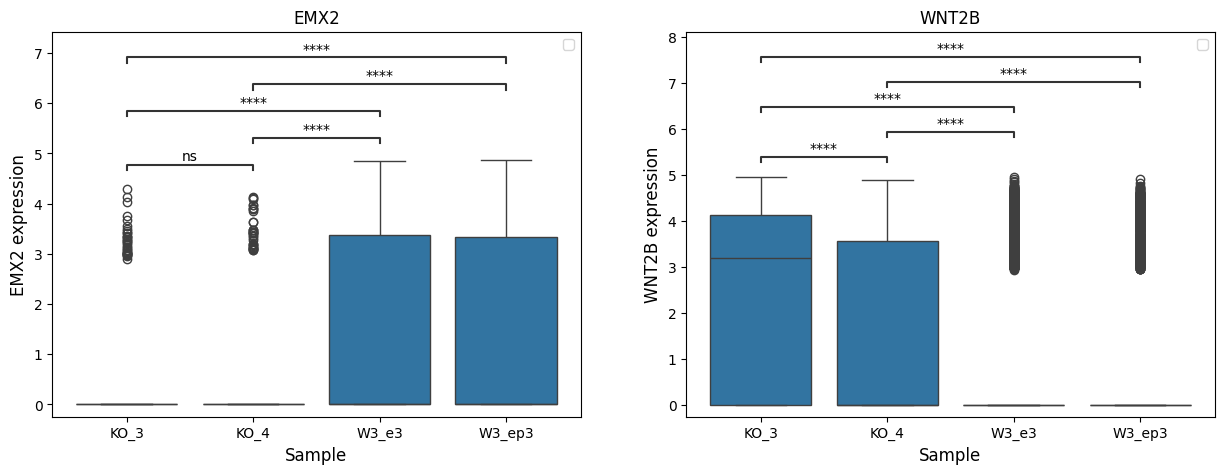

In [67]:
gene = 'EMX2'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[0].set_xlabel("Sample", fontsize= 12)
axs[0].set_ylabel(gene+" expression", fontsize= 12)
axs[0].set_title(gene, fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
gene= 'WNT2B'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
ax = sns.boxplot(ax = axs[1],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[1].set_xlabel("Sample", fontsize= 12)
axs[1].set_ylabel(gene+" expression", fontsize= 12)
axs[1].set_title(gene, fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
plt.savefig('/miridan-data/miridan/proj/NDE1/boxplot_WNT2B_EMX2_expression_by_samples.pdf',dpi=200)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:5.188e-02 U_stat=6.677e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.106e-58 U_stat=2.067e+06
KO_3 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:8.003e-111 U_stat=2.694e+06
KO_4 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.790e-33 U_stat=1.400e+06
KO_3 vs. W3_ep3: Mann-Whitney-Wilcoxon test two-sided, P_val:7.898e-64 U_stat=1.814e+06
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

KO_3 vs. KO_4: Mann-Whitney-Wilcoxon test two-sided, P_val:1.545e-10 U_stat=7.384e+05
KO_4 vs. W3_e3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.097e-65 U_stat=2.198e+06
KO_3 v

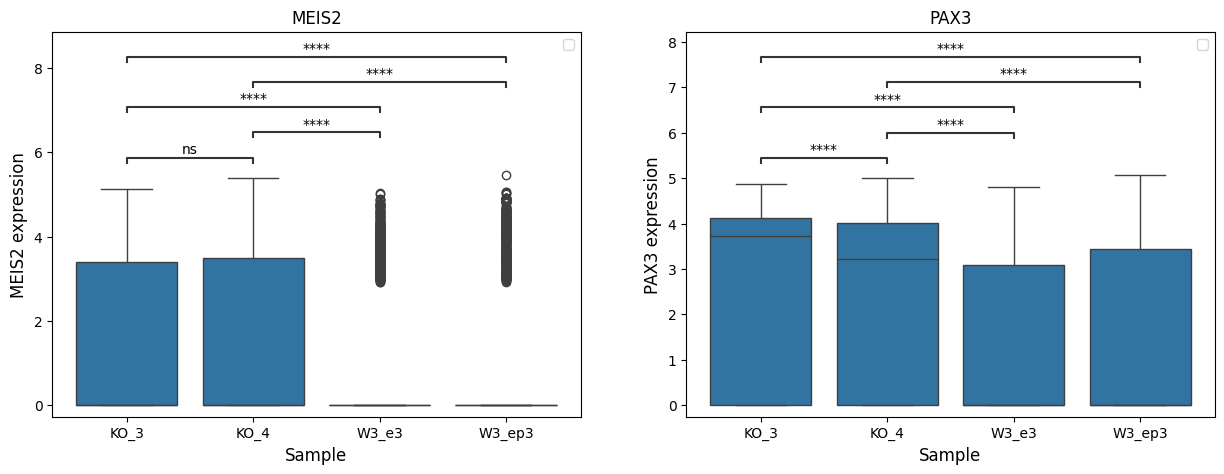

In [6]:
gene = 'MEIS2'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
fig, axs = plt.subplots(1,2,figsize=(15, 5))
ax = sns.boxplot(ax = axs[0],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[0].set_xlabel("Sample", fontsize= 12)
axs[0].set_ylabel(gene+" expression", fontsize= 12)
axs[0].set_title(gene, fontsize= 12)
axs[0].grid(False)
axs[0].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
gene= 'PAX3'
adata.obs[gene] =  adata.X[:,adata.var_names==gene].toarray().flatten()
ax = sns.boxplot(ax = axs[1],x='corrected.ident', y=gene,order= ['KO_3','KO_4','W3_e3','W3_ep3'] ,data=adata.obs)
axs[1].set_xlabel("Sample", fontsize= 12)
axs[1].set_ylabel(gene+" expression", fontsize= 12)
axs[1].set_title(gene, fontsize= 12)
axs[1].grid(False)
axs[1].legend('') 
#add_stat_annotation(ax, data=adata_RG_all_gt5_V3[np.where(adata_RG_all_gt5_V3.obs['NDE1']>0)[0],:].obs, x='Region1', y='NDE1',order= ['Forebrain','Midbrain','Hindbrain'],
#                    box_pairs=[('Forebrain', 'Midbrain'),( 'Midbrain', 'Hindbrain'),( 'Forebrain','Hindbrain')],
#                    test='Mann-Whitney-gt', text_format='star', loc='outside', verbose=2)

annotator = Annotator(ax, [('KO_3','KO_4'),( 'KO_3','W3_e3'),( 'KO_3','W3_ep3'),( 'KO_4','W3_e3'),( 'KO_4','W3_ep3')], data=adata.obs, x='corrected.ident', y=gene)
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()
plt.savefig('/miridan-data/miridan/proj/NDE1/boxplot_MEIS2_PAX3_expression_by_samples.pdf',dpi=200)


In [35]:
adata.X[:,adata.var_names=='FOXG1'].flatten()

array([], dtype=float64)